#Diabetes Prediction Model
**Dataset:** Pima Indians Diabetes Database: https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv

**Goal:** Train classification models to predict whether a patient has diabetes (`Outcome` = 1) from medical measurements.

**Notebook outline**
1. Data Loading & Exploration
2. Data Preprocessing
3. Model Training (Logistic Regression, Random Forest, SVM, Decision Tree, KNN)
4. Model Evaluation (Accuracy, Precision, Recall, F1, ROC-AUC, ROC curves)
5. Best Model Selection & Saving with `joblib`

# Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, ConfusionMatrixDisplay)

sns.set_style("whitegrid")
RANDOM_STATE = 42

# Data Loading and Exploration

In [ ]:
url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
df = pd.read_csv(url)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
#Dataset Shape
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Rows: 768, Columns: 9


In [ ]:
#Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
#Dataset Statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [ ]:
#Missing Values
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


# Impossible zeros
`isnull()` shows no missing values, but a value of **0** is medically impossible for `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin` and `BMI`. In this dataset zeros are placeholders for missing data.

In [ ]:
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
zero_counts = (df[zero_cols] == 0).sum().to_frame("zero_count")
zero_counts

,zero_count
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11


Outcome
0    500
1    268
Name: count, dtype: int64


/tmp/ipykernel_5423/2438896346.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Outcome", data=df, palette=["#4C78A8", "#E45756"])


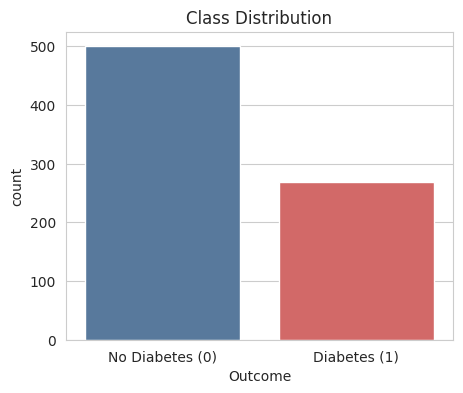

In [ ]:
#Target Distribution
counts = df["Outcome"].value_counts()
print(counts)

plt.figure(figsize=(5, 4))
sns.countplot(x="Outcome", data=df, palette=["#4C78A8", "#E45756"])
plt.xticks([0, 1], ["No Diabetes (0)", "Diabetes (1)"])
plt.title("Class Distribution")
plt.show()

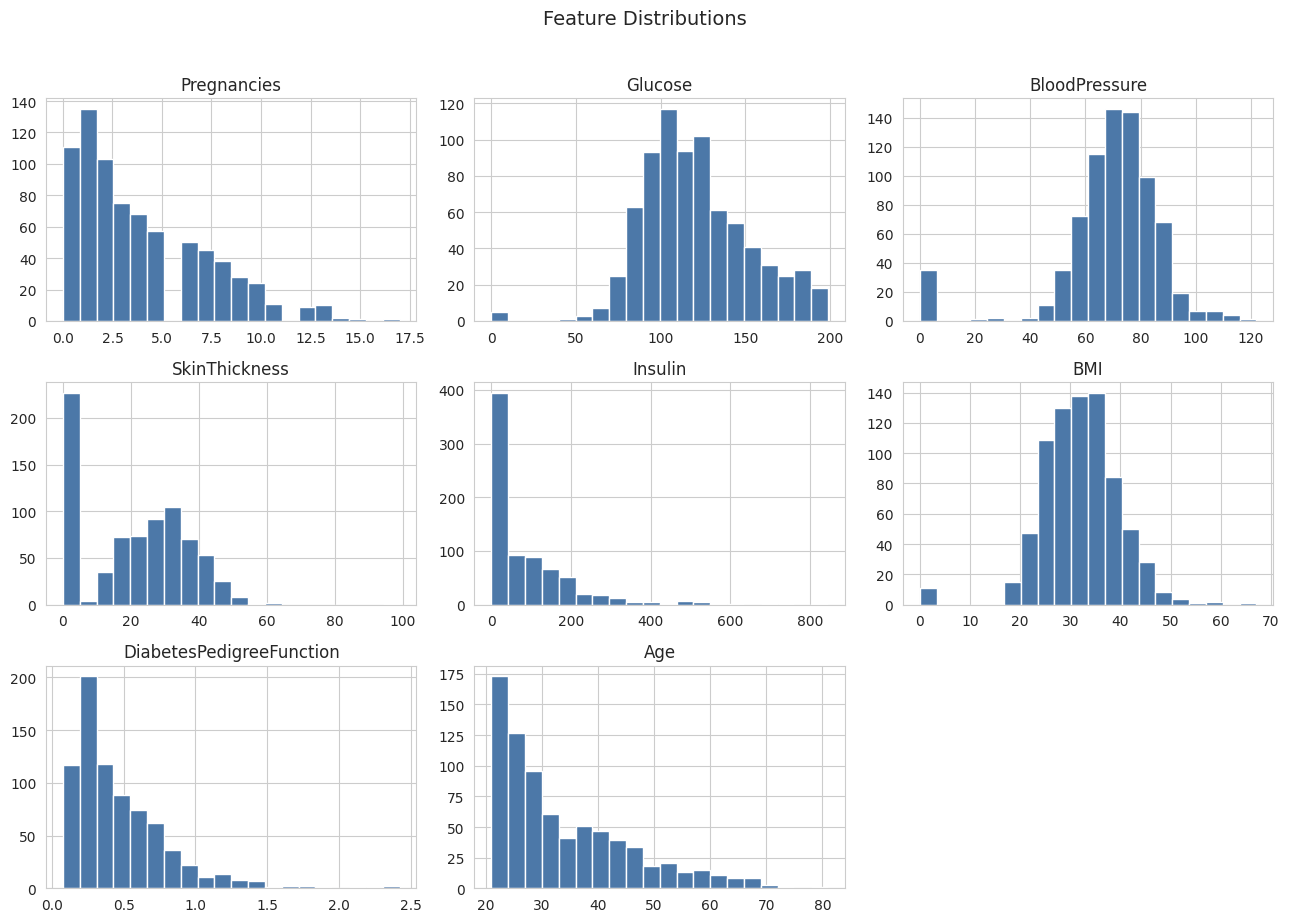

In [ ]:
#Feature Distributions
df.drop(columns="Outcome").hist(bins=20, figsize=(13, 9), color="#4C78A8", edgecolor="white")
plt.suptitle("Feature Distributions", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

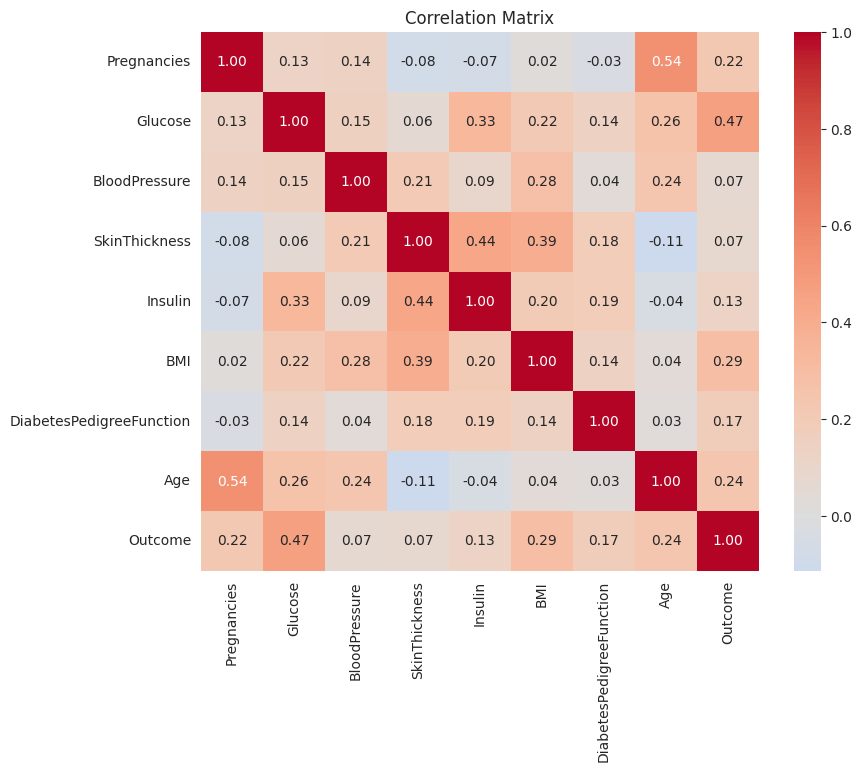

In [ ]:
#Correlation Heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

**Observations:** the dataset is moderately imbalanced. `Glucose` has the strongest correlation with `Outcome`, followed by `BMI`, `Age` and `Pregnancies`. Several columns contain impossible zeros that need to be handled during preprocessing.

# Data Preprocessing

In [ ]:
#Treat Impossible Zeros as Missing Values
df_clean = df.copy()
df_clean[zero_cols] = df_clean[zero_cols].replace(0, np.nan)
print("Missing values after replacing zeros:")
print("-------------------------------------")
print(df_clean.isnull().sum())

Missing values after replacing zeros:
-------------------------------------
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [ ]:
#Separate Features and Target
X = df_clean.drop("Outcome", axis=1)
y = df_clean["Outcome"]
print(f"X shape: {X.shape}, y shape: {y.shape[0]}")

X shape: (768, 8), y shape: 768


In [ ]:
#Train/Test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set : {X_test.shape[0]} samples")

Training set: 614 samples
Testing set : 154 samples


# Model Training
Five classifiers are trained. Each one is wrapped in a pipeline: **median imputer → standard scaler → classifier**.

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "SVM": SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(n_neighbors=7),
}

pipelines = {}
for name, clf in models.items():
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", clf),
    ])
    pipe.fit(X_train, y_train)
    pipelines[name] = pipe
    print(f"Trained: {name}")

Trained: Logistic Regression
Trained: Random Forest
Trained: SVM
Trained: Decision Tree
Trained: KNN


# Model Evaluation

In [ ]:
results = []
roc_data = {}

for name, pipe in pipelines.items():
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
    })
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_data[name] = (fpr, tpr, roc_auc_score(y_test, y_prob))

results_df = (pd.DataFrame(results)
              .set_index("Model")
              .sort_values("ROC-AUC", ascending=False)
              .round(4))
results_df

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Random Forest,0.7403,0.6591,0.5370,0.5918,0.8160
Logistic Regression,0.7078,0.6000,0.5000,0.5455,0.8130
SVM,0.7403,0.6522,0.5556,0.6000,0.7964
KNN,0.7273,0.6250,0.5556,0.5882,0.7900
Decision Tree,0.7597,0.6393,0.7222,0.6783,0.7622


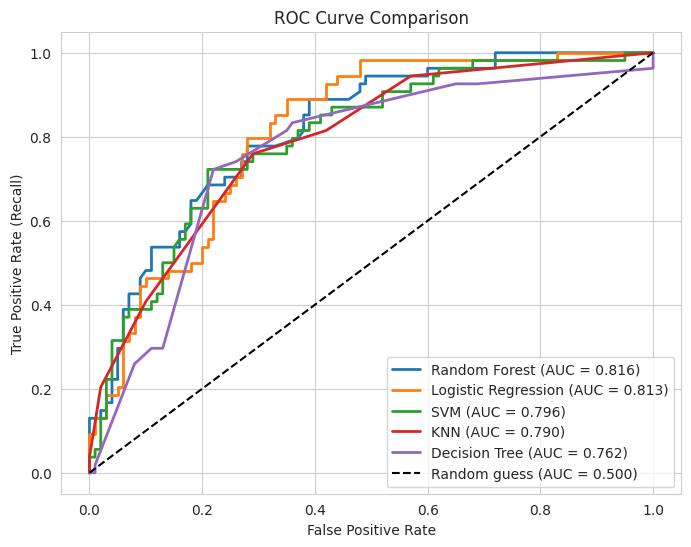

In [ ]:
#ROC Curve
plt.figure(figsize=(8, 6))
for name, (fpr, tpr, auc) in sorted(roc_data.items(), key=lambda kv: -kv[1][2]):
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random guess (AUC = 0.500)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.show()

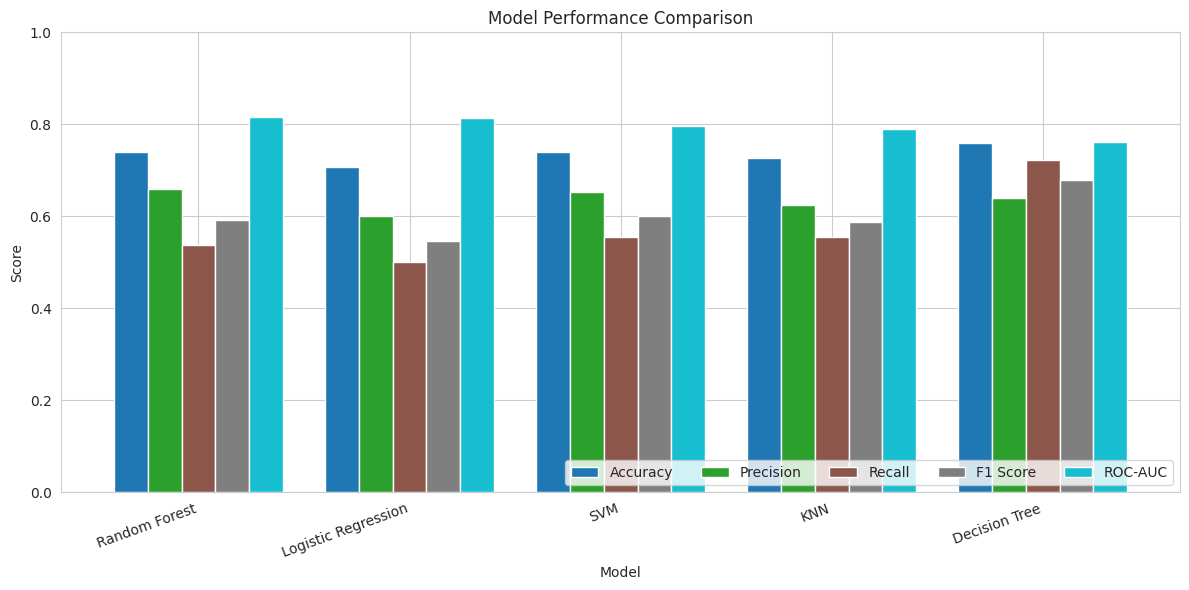

In [ ]:
#Visual Comparison of all Metrics
ax = results_df.plot(kind="bar", figsize=(12, 6), width=0.8, colormap="tab10", edgecolor="white")
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.legend(loc="lower right", ncol=5)
plt.tight_layout()
plt.show()

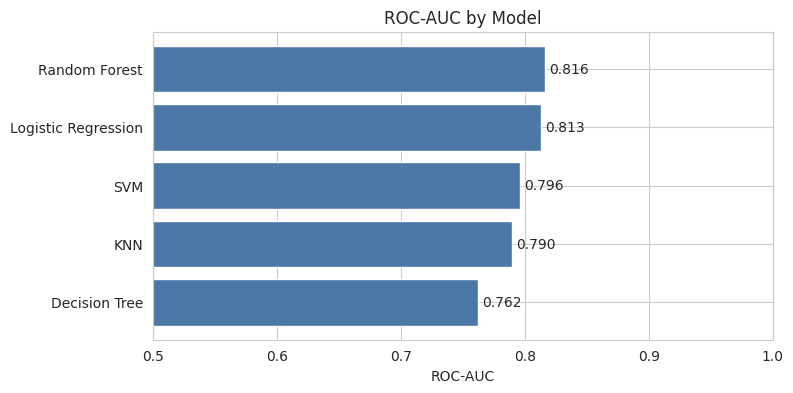

In [ ]:
#ROC-AUC Score Comparison
auc_sorted = results_df["ROC-AUC"].sort_values()
plt.figure(figsize=(8, 4))
bars = plt.barh(auc_sorted.index, auc_sorted.values, color="#4C78A8")
plt.bar_label(bars, fmt="%.3f", padding=3)
plt.xlim(0.5, 1.0)
plt.xlabel("ROC-AUC")
plt.title("ROC-AUC by Model")
plt.show()

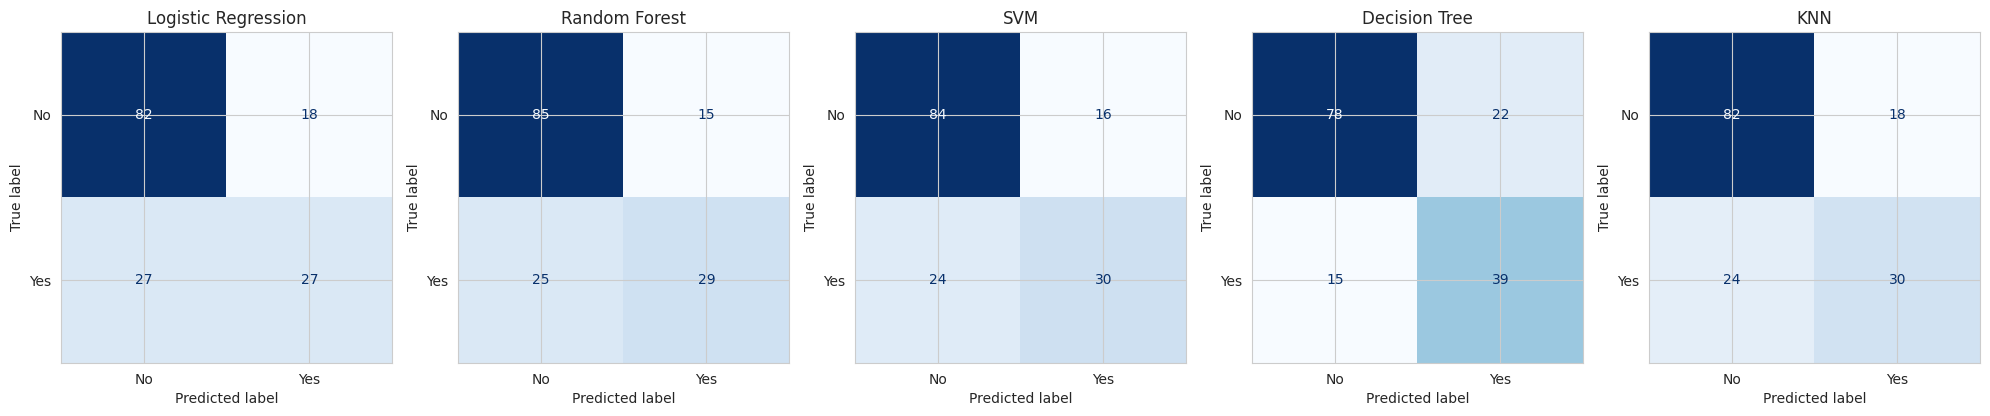

In [ ]:
#Confusion Matrices
fig, axes = plt.subplots(1, len(pipelines), figsize=(4 * len(pipelines), 4))
for ax, (name, pipe) in zip(axes, pipelines.items()):
    cm = confusion_matrix(y_test, pipe.predict(X_test))
    ConfusionMatrixDisplay(cm, display_labels=["No", "Yes"]).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
plt.tight_layout()
plt.show()

# Best Model Selection & Saving
The best model is selected by **ROC-AUC** on the test set, because it measures ranking quality across all classification thresholds and is robust to the class imbalance. In a medical setting, **Recall** also matters (missing a diabetic patient is costly), so it is shown alongside.

In [ ]:
best_name = results_df["ROC-AUC"].idxmax()
best_model = pipelines[best_name]

print(f"Best model: {best_name}")
print(results_df.loc[best_name].to_string())

Best model: Random Forest
Accuracy     0.7403
Precision    0.6591
Recall       0.5370
F1 Score     0.5918
ROC-AUC      0.8160


In [ ]:
#Save The Best Model (the whole pipeline: imputer + scaler + classifier)
joblib.dump(best_model, "diabetes_model.pkl")
print("Model saved as diabetes_model.pkl")

Model saved as diabetes_model.pkl
